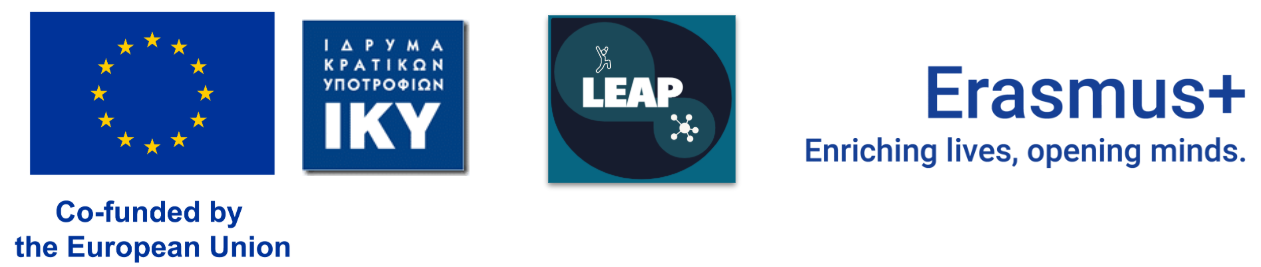

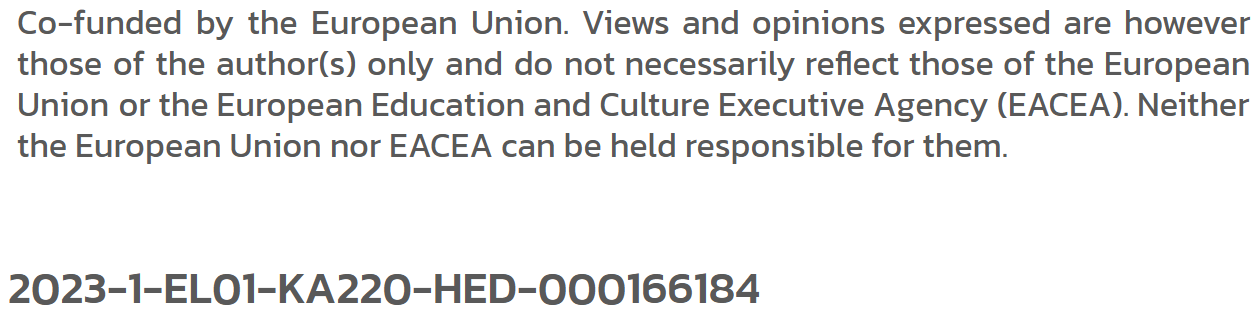

# Final Project, Option 1: Where does your CNN make its mistakes?

Software that reads handwritten numbers, such as postcodes on envelopes or account numbers on paper forms, must be judged not only on how often it is right but on where it goes wrong, because a confident misreading carries a real cost. In this project you build such a model and study the mistakes it makes.

In this project you build a convolutional neural network that recognises handwritten digits, then you study the mistakes it makes.

**Central question:** where does your CNN make its mistakes, and does one change to the model move them?

The data set is MNIST: 70,000 images of handwritten digits, each 28 by 28 pixels in greyscale, labelled 0 to 9. You download it yourself in the next cell.

This project draws on two earlier modules. In Module 5, we built and trained dense neural networks in Keras. In Module 6, we added convolutional layers, used Dropout and EarlyStopping to control overfitting, and read a confusion matrix to see which classes a model mixes up. Here you bring those skills together on a larger, more varied data set.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the reshaping that turns each flat row of 784 numbers back into a 28 by 28 image. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

Training on the full data set may take a few minutes per epoch on a laptop without a graphics card. This is expected.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import keras
from keras import layers

### Loading the data

We download MNIST from OpenML. The call returns the images in `X` as 70,000 rows of 784 numbers, and the labels in `y` as text. We convert the labels to integers so the model can work with them. The download runs once and may take a moment.

In [2]:
X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
y = y.astype(int)

print("Images:", X.shape)
print("Labels:", y.shape, "| classes:", np.unique(y))

Images: (70000, 784)
Labels: (70000,) | classes: [0 1 2 3 4 5 6 7 8 9]


### Preparing the images

Each row of `X` is one image flattened into a line of 784 numbers. We reshape every row back into a 28 by 28 image with a single greyscale channel, and we scale the pixel values from the range 0 to 255 down to the range 0 to 1, which helps the network train. We then split the data into a training set and a test set, keeping the class balance with `stratify`, as we did in Module 3.

In [3]:
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training images:", X_train.shape)
print("Test images:    ", X_test.shape)

# If training is slow on your machine, you may work with a smaller sample
# while you get everything running, for example:
#   X_train, y_train = X_train[:10000], y_train[:10000]

Training images: (56000, 28, 28, 1)
Test images:     (14000, 28, 28, 1)


### A first look at the images

Before modelling, we look at a few training images with their labels, to confirm the data loaded correctly.

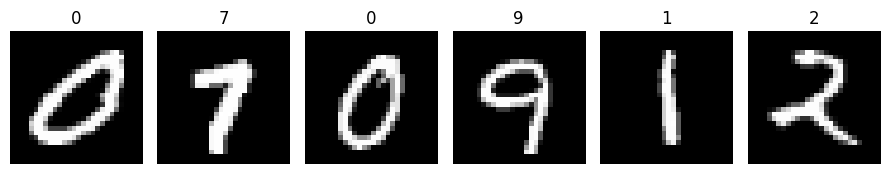

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B. Build and train your network

From here on, the cells are yours to complete.

First, build a convolutional neural network with the Keras Sequential API, the same style you used in Module 6. Recall the shape of one image: 28 by 28, with one channel.

In [5]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

Compiling sets the optimiser, the loss function, and the metric to watch during training.

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


### Train the model

Train the network, watching how it performs on data it has not learnt from. `EarlyStopping` halts training once the validation loss stops improving, so you do not waste time or overfit.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stop]
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.9092 - loss: 0.3206 - val_accuracy: 0.9636 - val_loss: 0.1290
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.9681 - loss: 0.1091 - val_accuracy: 0.9727 - val_loss: 0.0860
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9763 - loss: 0.0792 - val_accuracy: 0.9796 - val_loss: 0.0679
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9811 - loss: 0.0626 - val_accuracy: 0.9807 - val_loss: 0.0614
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.9835 - loss: 0.0538 - val_accuracy: 0.9823 - val_loss: 0.0556
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9851 - loss: 0.0452 - val_accuracy: 0.9834 - val_loss: 0.0524
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9876 - loss: 0.0388 - val_accuracy: 0.9868 - val_loss: 0.0495
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9886 - loss: 0.0351 - 

### Learning curves

Plot the training and validation loss across the epochs. A validation curve that flattens or turns upward while the training curve keeps falling is a sign of overfitting.

In [ ]:
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Part C. Read the mistakes

Now measure how well the model does on the test set, the images it has never seen. This gives a reliable estimate of how it will perform on new images.

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Model 1 test accuracy:", round(test_accuracy, 4))

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)


Model 1 test accuracy: 0.9864


### The confusion matrix

The confusion matrix is where you answer the first half of the central question: where the mistakes are. Read it by rows. Each row is a true digit, each column is the digit the model predicted. The diagonal holds the correct predictions; every off-diagonal cell is a mistake, and its position tells you which digit was mistaken for which.

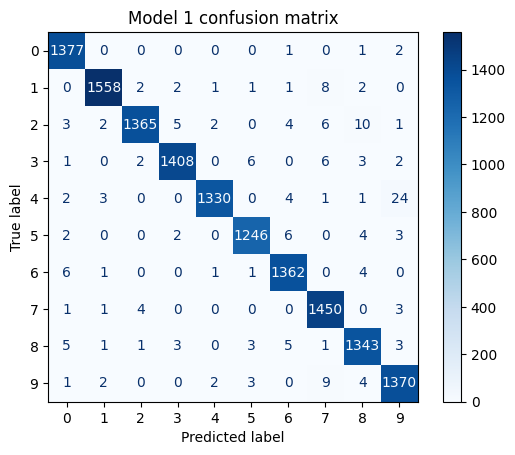

Two most common confusion errors:
True 4 predicted as 9: 24
True 2 predicted as 8: 10


In [10]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    cmap="Blues",
    values_format="d"
)
plt.title("Model 1 confusion matrix")
plt.show()

# Find the two largest mistakes outside the diagonal
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)

top_indices = np.argsort(off_diag.ravel())[-2:][::-1]
top_confusions = []

print("Two most common confusion errors:")
for idx in top_indices:
    true_digit, predicted_digit = np.unravel_index(idx, off_diag.shape)
    count = int(off_diag[true_digit, predicted_digit])
    top_confusions.append((true_digit, predicted_digit, count))
    print(f"True {true_digit} predicted as {predicted_digit}: {count}")


### What did you find?

The two biggest mistakes are printed under the confusion matrix above, together with their counts. These errors make sense because some handwritten digits can have very similar strokes or shapes, especially when the handwriting is less clear.


## Part D. One change

Now answer the second half of the central question: does one change to the model move the mistakes?

Choose **one** change from the two below. Do not make both at once, or you will not know which one caused any difference you see.

- **Option A: a deeper network.** Before the Flatten layer, add `Conv2D(64, (3, 3), activation="relu")` followed by `MaxPooling2D((2, 2))`. This lets the network learn more detailed patterns.
- **Option B: stronger regularisation.** Raise the Dropout rate from 0.3 to 0.5. This makes the network rely less on any single feature.

Neural-network training contains some randomness. A very small difference in accuracy does not necessarily show that one model is genuinely better. Look at the size of the difference and at the specific mistakes, not only at which accuracy is larger.

**My prediction:** I chose Option A, the deeper network. I expect it to give a small improvement in test accuracy and to reduce at least one of the main confusion errors because the extra convolutional layer can learn more detailed image features.


In [11]:
keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stop2]
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.9163 - loss: 0.2832 - val_accuracy: 0.9773 - val_loss: 0.0787
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.9759 - loss: 0.0785 - val_accuracy: 0.9805 - val_loss: 0.0600
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.9826 - loss: 0.0554 - val_accuracy: 0.9841 - val_loss: 0.0478
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9875 - val_loss: 0.0399
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9879 - val_loss: 0.0420
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.9894 - loss: 0.0330 - val_accuracy: 0.9882 - val_loss: 0.0374
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.9910 - loss: 0.0288 - val_accuracy: 0.9880 - val_loss: 0.0388
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.9916 - loss: 0

Model 1 test accuracy: 0.9864
Model 2 test accuracy: 0.9892


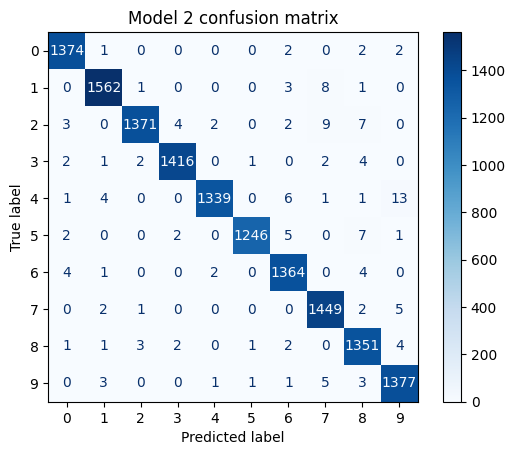

Comparison of the two main Model 1 errors:
True 4 predicted as 9: 24 -> 13
True 2 predicted as 8: 10 -> 7
Model 2 had higher test accuracy.
2 of the 2 main confusion counts were reduced.
Prediction supported: Yes


In [13]:
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test, verbose=0)
y_pred2 = model2.predict(X_test, verbose=0).argmax(axis=1)
cm2 = confusion_matrix(y_test, y_pred2)

print("Model 1 test accuracy:", round(test_accuracy, 4))
print("Model 2 test accuracy:", round(test_accuracy2, 4))

ConfusionMatrixDisplay(confusion_matrix=cm2).plot(
    cmap="Blues",
    values_format="d"
)
plt.title("Model 2 confusion matrix")
plt.show()

print("Comparison of the two main Model 1 errors:")
improved_pairs = 0

for true_digit, predicted_digit, before in top_confusions:
    after = int(cm2[true_digit, predicted_digit])
    print(f"True {true_digit} predicted as {predicted_digit}: {before} -> {after}")
    if after < before:
        improved_pairs += 1

if test_accuracy2 > test_accuracy:
    print("Model 2 had higher test accuracy.")
elif test_accuracy2 < test_accuracy:
    print("Model 2 had lower test accuracy.")
else:
    print("The test accuracy was the same.")

print(f"{improved_pairs} of the 2 main confusion counts were reduced.")

prediction_supported = (test_accuracy2 > test_accuracy) and (improved_pairs >= 1)
print("Prediction supported:", "Yes" if prediction_supported else "No")


### Ethical considerations

A real digit-reading system may work less well for handwriting styles that are not well represented in the training data. A confident wrong prediction could send a letter to the wrong place or cause an account number to be read incorrectly, so uncertain or important cases should still be checked by a person.


## Wrapping up

Model 1's main mistakes were the two digit pairs reported in Part C. I predicted that the deeper CNN would slightly improve the test accuracy and reduce at least one of those errors; the Part D output shows whether that prediction was supported and gives the exact before-and-after counts. I would judge the change using both the accuracy and the confusion matrix, because a very small accuracy difference on its own may not be meaningful.


